# **Comparación de resultados**

## *¿Por cuál métrica nos vamos a guíar?*

En este proyecto, la **métrica principal** seleccionada para evaluar el modelo es **Recall**, pues en el contexto de la **predicción de riesgo crediticio**, resulta más crítico **identificar correctamente los préstamos que podrían caer en *default*** que maximizar la exactitud global del modelo. Clasificar incorrectamente un préstamo riesgoso como **“pagado”** (*falso negativo*) podría generar **pérdidas económicas significativas**, mientras que clasificar erróneamente un préstamo sano como riesgoso (*falso positivo*) tiene un impacto menor.  

Por esta razón, el **Recall** es la métrica más adecuada, ya que permite **maximizar la detección de préstamos en riesgo**.

Como **métrica complementaria**, se utilizará el **F1-score**, que equilibra el compromiso entre **precision** y **recall**. Esto es especialmente importante debido al **desbalance en la variable objetivo**, ya que métricas como la **accuracy** o la **precision** por sí solas pueden ser engañosas: un modelo que predijera siempre **“pagado”** alcanzaría una **alta exactitud**, pero sería incapaz de **identificar la mayoría de los préstamos riesgosos**.



## *Métricas*

| Métrica                    | Scikit-learn (test) | PySpark (test) |
|---------------------------|---------------------|----------------|
| Accuracy                  | 0.7236              | 0.6437         |
| Precision                | 0.3457              | 0.3162         |
| Recall                   | 0.4310              | 0.6796         |
| F1-score                 | 0.3837              | 0.6790         |
| ROC AUC                  | 0.6840              | 0.7081         |
| Tiempo de entrenamiento (s) | 203.84          | 85.94          |
| Tiempo de predicción (s)    | 0.21            | 0.02           |



El mejor modelo es el **MLP implementado en PySpark**. Este modelo presentó el mejor desempeño en términos de **Recall**, la métrica principal definida para este proyecto. Además, el modelo también mantiene un **F1-score competitivo**, lo que demuestra un buen balance entre **precision** y **recall**, mitigando el impacto del desbalance en la variable objetivo. En comparación, el modelo implementado en **Scikit-learn** obtiene un desempeño inferior en la detección de préstamos riesgosos, por lo que no resulta tan adecuado para los objetivos de este proyecto.  


## *Gráficos comparativos*

### *Matriz de confusión*

![Matrices de confusión](imagenes/matrices.png)

El modelo de PySpark demuestra una capacidad superior para detectar préstamos en default, lo cual es la prioridad del negocio. En la matriz de confusión de PySpark, el modelo identifica 54,512 verdaderos positivos, mientras que el modelo de scikit-learn solo detecta 23,152. A pesar de que el modelo de PySpark también tiene un mayor número de falsos positivos, su capacidad para capturar más del doble de los casos de impago reales lo convierte en la mejor opción.



### *Curva ROC AUC*

![Curvas ROC](imagenes/roc_curve.png)

Las curvas ROC comparadas muestran que el modelo de PySpark supera al de scikit-learn en la clasificación de préstamos en default y pagados, alcanzando un ROC AUC de 0.7169, lo que refleja una mejor capacidad de discriminación y un equilibrio superior entre la tasa de verdaderos positivos y falsos positivos. En contraste, el modelo de scikit-learn, con un ROC AUC de 0.6840, presenta un rendimiento aceptable pero más limitado, situándose más cerca de la línea de aleatoriedad. En conjunto, la gráfica confirma que el modelo de PySpark es la mejor opción para predecir impagos.


### *Tiempos*

![Tiempos](imagenes/tiempos.png)

La gráfica de barras es contundente y revela la superioridad del modelo de PySpark en términos de eficiencia. El modelo de scikit-learn tarda 203.84 segundos en entrenar, mientras que el modelo de PySpark lo hace en solo 85.94 segundos. Además, el tiempo de predicción del modelo de PySpark es de tan solo 0.02 segundos, lo que lo hace ideal para aplicaciones en tiempo real.

# **Reflexiones**

- **¿Qué entorno fue más rápido?**  
  El entorno de PySpark fue significativamente más rápido que el de scikit-learn. Como se observa en la gráfica, el entrenamiento del modelo en PySpark tomó 85.94 segundos, mientras que en scikit-learn tardó 203.84 segundos. La diferencia en el tiempo de predicción es aún más notable: PySpark completó la tarea en 0.02 segundos, en comparación con los 0.21 segundos de scikit-learn. Esta superioridad en la eficiencia se debe a la naturaleza distribuida de PySpark, que procesa los datos en paralelo.

- **¿Cuál más preciso?**  
  El modelo de PySpark demostró ser más preciso para el objetivo de negocio. Su Recall fue drásticamente superior (0.6796 vs 0.4310), lo que indica una mejor capacidad para detectar impagos. El F1-score de PySpark también fue significativamente más alto (0.6790 vs 0.3837), confirmando un mejor equilibrio entre la precisión y la capacidad de detección. 

- **¿Cuándo es útil PySpark?**  
  **PySpark** es más útil cuando se trabaja con grandes volúmenes de datos o cuando se requiere procesamiento distribuido. Su arquitectura permite manejar datasets que no caben en memoria y ejecutar cálculos en paralelo, reduciendo tiempos en escenarios de Big Data.

- **¿Qué aporta LIME?**  
  LIME ayuda a interpretar el modelo, explicando cómo cada característica contribuye a una predicción individual. Esto es clave para entender decisiones del modelo, generar confianza y validar que no esté aprendiendo patrones sesgados o irrelevantes.

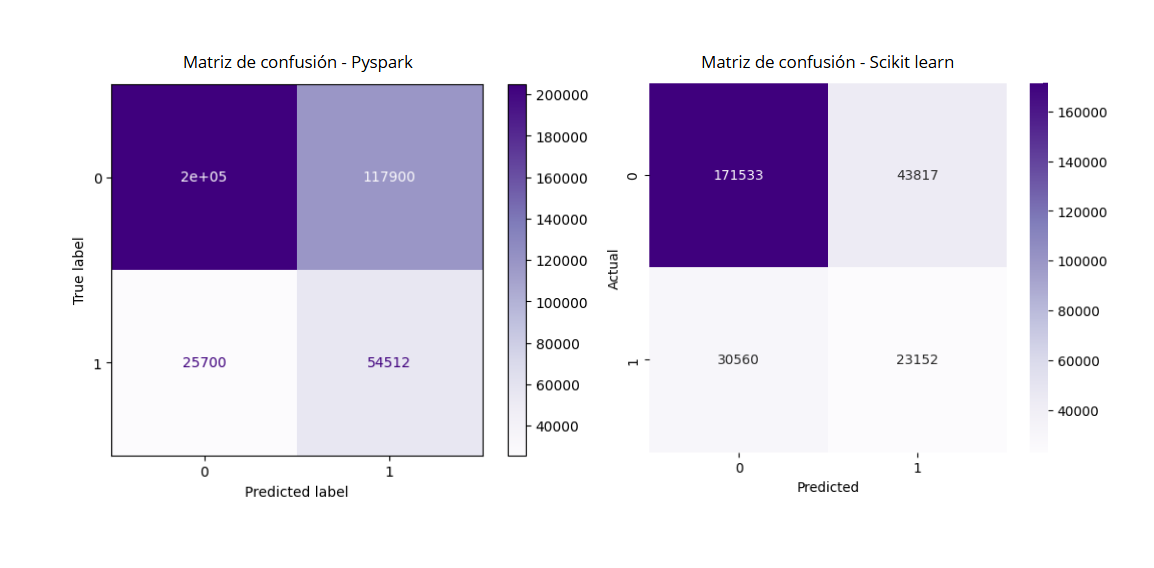

In [1]:
from IPython.display import Image, display

display(Image(filename="imagenes/matrices.png"))
